# n-DOF articulated Ziegler column: keep-B vs symbolic inversion

The Ziegler column is a chain of $n$ rigid links with torsional springs/dampers at
the joints and a follower force $P$ at the tip. 

With absolute link angles $\theta=(\theta_1,\dots,\theta_n)$ ($n$ = number of links)
and state $x=[\theta,\dot\theta]^\top$, the equations of motion are

$$
 B(x)\,\dot x = F(x),\qquad
B(x)=\begin{bmatrix} I & 0\\ 0 & M(\theta)\end{bmatrix},\qquad
F(x)=\begin{bmatrix}\dot\theta\\[4pt] -K\theta-C\dot\theta+p(\theta)+q(\theta,\dot\theta)\end{bmatrix}. 
$$
We assume all links are of equal lengths, and that all joints have identical torsional springs $k$, damping constants $c$ and masses $m=1$. Then, the terms in the EOM are: 

Mechanical mass matrix
$$ M_{ij}(\theta)=\bigl(n+1-\max(i,j)\bigr)\cos(\theta_i-\theta_j),\qquad$$

Stiffness and damping matrices
$$ K=k\begin{bmatrix} 2 & -1 & & & \\ -1 & 2 & -1 & & \\ & \ddots & \ddots & \ddots & \\ & & -1 & 2 & -1 \\ & & & -1 & 1 \end{bmatrix},\qquad C=\tfrac{c}{k}\,K. $$

Generalized follower force
$$p_i(\theta)=P\sin(\theta_i-\theta_n), $$

Nonlinearity
$$ q_i(\theta,\dot\theta)=-\sum_{j=1}^{n}\bigl(n+1-\max(i,j)\bigr)\sin(\theta_i-\theta_j)\,\dot\theta_j^{2}. $$

We parametrize the 2-D spectral submanifold tangent to the slowest mode in coordinates $p=[z,\bar{z}]\in \mathbb{C}^2$
two ways:

- **invert-B** : compute inverse $B^{-1}(x)$ symbolically (cofactor expansion), then use $B^{-1}(x)F(x)$ as the new vector field.
- **keep-B** : keep $B=B(x)$ in the LHS, thus $F(x)=F(W(p))$ and $B(x)=B(W(p))$ each have their own polynomial series.

## References

1. H. Ziegler, *Die Stabilitätskriterien der Elastomechanik*, Ingenieur-Archiv **20** (1952) 49–56 — the original (2-DOF) follower-force column.
2. V. V. Bolotin, *Nonconservative Problems of the Theory of Elastic Stability*, Pergamon Press, 1963 — the discretized $N$-segment follower-force column.
3. A. Luongo & F. D'Annibale, *On the effects of linear damping on the nonlinear Ziegler's column*, Nonlinear Dynamics **101** (2020) 791–814 — nonlinear dynamics of the damped Ziegler column.

In [1]:
include(joinpath(@__DIR__, "..", "import_all.jl"))
using Plots, Printf, LinearAlgebra, Symbolics
gr()



  ____       _ _     ___  __  __       ____  
 |  _ \ ___ | (_)   |_ _||  \/  | __ _|  _ \ 
 | |_) / _ \| | | __ | | | |\/| |/ _` | |_)|
 |  __/ (_) | | ||__|| | | |  | | (_| |  __/ 
 |_|   \___/|_|_|   |___||_|  |_|\__,_|_|    

 Poli's Invariant Manifold Parametrizer 
 Source: github.com/nonlinear-dynamics-in-engineering/Poli-IMaP




Plots.GRBackend()

In [ ]:
const D = Complex{Float64} # datatype
const KSPRING = 1.0        # torsion spring constant
const CDAMP = 0.1          # damping constant
const PFOLL = 1.0          # follower force
const KAUT = 5             # expansion order

acoef(i, j, n) = n + 1 - max(i, j)    # lumped mass coupling
function Lrow(i, v, n)                # (tridiagonal L · v)_i
    s = (i == n ? 1.0 : 2.0) * v[i]
    i > 1 && (s = s - v[i-1])
    i < n && (s = s - v[i+1])
    s
end
Mentry(i, j, θ, n) = acoef(i, j, n) * cos(θ[i] - θ[j])

# i-th θ̈-equation RHS:  -Kθ - Cθ̇ + follower + nonlinear
function rhs2(i, θ, θd, n)
    e = -KSPRING * Lrow(i, θ, n) - CDAMP * Lrow(i, θd, n)
    for j in 1:n
        j == i && continue
        e = e - acoef(i, j, n) * sin(θ[i] - θ[j]) * θd[j]^2
    end
    i != n && (e = e + PFOLL * sin(θ[i] - θ[n]))
    e
end

Ffield(x, n) = vcat([x[n+i] for i in 1:n], [rhs2(i, x[1:n], x[n+1:2n], n) for i in 1:n])

Bpattern(n)= vcat([(i, i) for i in 1:n], [(n+i, n+j) for i in 1:n for j in 1:n])
Bvals(x, n) = vcat([1.0 for _ in 1:n], [Mentry(i, j, x[1:n], n) for i in 1:n for j in 1:n])

minor(A, r, c) = A[setdiff(axes(A,1), r), setdiff(axes(A,2), c)]

settings(n) = (autidxs = collect(1:2n), 
               tgaxes = [1, 2], 
               auttgaxes = [1, 2],
               fullspectrum = true, 
               parstyle = "resonant",
               resonances = Dict(1 => (1, -1), 2 => (-1, 1)), 
               kaut = KAUT)

# keep-B: parametrize with the explicit mass-matrix descriptor B = [I, 0; 0, M(θ)]
function run_keepB(n)
    sys = System{D}(F = z -> Ffield(z, n), 
                    B = z -> Bvals(z, n), 
                    Bpattern = Bpattern(n),
                    ddim = 2n, 
                    rdim = 2,
                    D = D, 
                    maxorder = 20)

    initialize_system!(sys); 
    linearize_system!(sys)
    parametrize_autonomous!(sys, set_parametrization_settings(sys; settings(n)...))
    return sys
end

# invert-B: absorb the symbolic inverse M(θ)⁻¹ (cofactor expansion) into the field
function run_invertB(n)
    @variables θ[1:n] θd[1:n]
    θv = collect(θ); θdv = collect(θd)
    M = [Mentry(i, j, θv, n) for i in 1:n, j in 1:n]
    rhs = [rhs2(i, θv, θdv, n) for i in 1:n]
    detM = det(M)
    adj = [(-1)^(i+j) * det(minor(M, j, i)) for i in 1:n, j in 1:n]
    G  = (adj * rhs) ./ detM
    Ffun = eval(build_function(vcat(θdv, G), vcat(θv, θdv))[1])
    sys = System{D}(F = z -> Base.invokelatest(Ffun, z), ddim = 2n, rdim = 2, D = D, maxorder = 20)
    initialize_system!(sys); linearize_system!(sys)
    parametrize_autonomous!(sys, set_parametrization_settings(sys; settings(n)...))
    return sys
end

run_invertB (generic function with 1 method)

In [ ]:
function run_benchmark(dofs)
    redirect_stdout(devnull) do            # warm up / compile at n = 2
        run_keepB(2); run_invertB(2)
    end
    ns = Int[]; tkeep = Float64[]; tinv = Float64[]; nk = Int[]; ni = Int[]; dW = Float64[]
    println("\n  n |  keep-B    |  invert-B (M⁻¹)        |  F-nodes keep/inv |  max|ΔW|")
    println(  "----+------------+-----------------------+------------------+---------")
    for n in dofs
        tk = @elapsed (sk = run_keepB(n))
        ti = @elapsed (si = run_invertB(n))
        d = maximum(abs, sk.W.tensors .- si.W.tensors)
        push!(ns, n); push!(tkeep, tk); push!(tinv, ti)
        push!(nk, length(sk.gF.ndlist)); push!(ni, length(si.gF.ndlist)); push!(dW, d)
        @printf("%3d | %8.4fs  | %8.4fs %7.1fx | %6d / %-7d | %.1e\n",
                n, tk, ti, ti/tk, length(sk.gF.ndlist), length(si.gF.ndlist), d)
    end
    println("\nKAUT = $KAUT.  invert-B = symbolic cofactor inverse + bake into F + parametrize;")
    println("keep-B = parametrize with F + B(θ) = blkdiag(I, M(θ)).")
    return ns, tkeep, tinv, nk, ni, dW
end

ns, tkeep, tinv, nk, ni, dW = run_benchmark([2, 3, 4, 5]);

Progress:  50%[==========>         ]  ETA: 0:00:00


  n |  keep-B    |  invert-B (M⁻¹)        |  F-nodes keep/inv |  max|ΔW|
----+------------+-----------------------+------------------+---------
Building graph of F... done
Building graph of B... done (6 nonzero entries).
Computing B(0)... done

Computing Jacobian of F... done
Computing full spectrum... done
Starting autonomous parametrization.
Autonomous parametrization complete.
Building graph of F... done
Building graph of B... B matrix found to be constant... done
Computing Jacobian of F... done
Computing full spectrum... done
Starting autonomous parametrization.
Autonomous parametrization complete.
  2 |   0.0008s  |   0.1641s   207.0x |     49 / 144     | 3.3e-16
Building graph of F... done
Building graph of B... done (12 nonzero entries).
Computing B(0)... done

Computing Jacobian of F... done
Computing full spectrum... done
Starting autonomous parametrization.
Autonomous parametrization complete.
Building graph of F... done
Building graph of B... B matrix found to be constant..

## Timing (log scale)
`keep-B` exec time is nearly constant for nDOF = 2 to 5.

`invert-B` exec time grows exponentially due to the added number of operations.

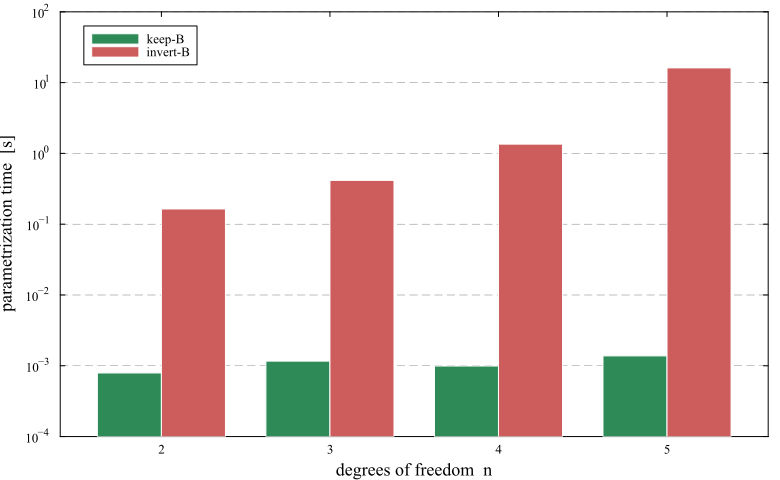

In [ ]:
allt = filter(isfinite, vcat(tkeep, tinv))
ylo = 10.0 ^ floor(log10(minimum(allt)))
yhi = 10.0 ^ ceil(log10(maximum(allt)))
w = 0.38
Plots.default(fontfamily = "Times New Roman")

p = bar(ns .- w/2, tkeep; bar_width = w, fillto = ylo,
        label = "keep-B", color = :seagreen, linecolor = :white,
        yscale = :log10, ylims = (ylo, yhi),
        xticks = (ns, string.(ns)), xlabel = "degrees of freedom  n",
        ylabel = "parametrization time  [s]",
        legend = :topleft, framestyle = :box, size = (780, 480),
        grid = :y, gridalpha = 0.25, gridstyle = :dash)
bar!(ns .+ w/2, tinv; bar_width = w, fillto = ylo, color = :indianred,
     linecolor = :white, label = "invert-B")
p